In [5]:
import xarray as xr
import os
import glob

In [6]:
basedir = "/gws/nopw/j04/co2clim/datasets/iCESM1.2_Eocene/"
os.listdir(basedir)

['b.e12.B1850C5CN.f19_g16.iPETM01x.02.pop.h.2701-2800.climo.nc',
 'b.e12.B1850C5CN.f19_g16.iPETM03x.03.pop.h.2101-2200.climo-012.nc',
 'b.e12.B1850C5CN.f19_g16.iPETM03x.OrbMaxN.01.pop.h.2601-2700.climo-014.nc',
 'b.e12.B1850C5CN.f19_g16.iPETM03x.OrbMaxS.01.pop.h.2601-2700.climo-017.nc',
 'b.e12.B1850C5CN.f19_g16.iPETM03x.OrbMin.01.pop.h.2601-2700.climo-011.nc',
 'b.e12.B1850C5CN.f19_g16.iPETM06x.09.pop.h.2101-2200.climo-018.nc',
 'b.e12.B1850C5CN.f19_g16.iPETM06x.OrbMaxN.01.pop.h.2601-2700.climo-015.nc',
 'b.e12.B1850C5CN.f19_g16.iPETM06x.OrbMaxS.01.pop.h.2601-2700.climo-001.nc',
 'b.e12.B1850C5CN.f19_g16.iPETM06x.OrbMin.01.pop.h.2601-2700.climo-016.nc',
 'b.e12.B1850C5CN.f19_g16.iPETM09x.02.pop.h.2101-2200.climo-019.nc',
 'b.e12.B1850C5CN.f19_g16.iPI.02.pop.h.0101-0200.climo-010.nc',
 'iCESM1.2_Eocene-20250531T164709Z-1-003.zip',
 'iCESM1.2_Eocene-20250531T164709Z-1-007.zip',
 'iCESM1.2_Eocene-20250531T164709Z-1-021.zip',
 'iCESM1.2_Eocene-20250531T164709Z-1-023.zip',
 'iCESM1.2_Eocen

In [7]:
### PREPROCESS FUNCTION
def preprocess(ds):
    filename = ds.encoding["source"]
    filename_elements = filename.split(".")
    experiment = filename_elements[5]
    orbconfig = filename_elements[6]
    if orbconfig[:3]=="Orb":
        experiment += '.'+orbconfig
    timespan = filename_elements[-3]
    print(experiment,end=', ')
    print(timespan,end='\n')
    # place experiment as distinct dimension
    ds = ds.squeeze().expand_dims({'experiment':[experiment]})
    return ds

In [8]:
filename = "b.e12.B1850C5CN.f19_g16.iPETM0[1369]*.nc"
paths = glob.glob(basedir+filename)
paths

['/gws/nopw/j04/co2clim/datasets/iCESM1.2_Eocene/b.e12.B1850C5CN.f19_g16.iPETM01x.02.pop.h.2701-2800.climo.nc',
 '/gws/nopw/j04/co2clim/datasets/iCESM1.2_Eocene/b.e12.B1850C5CN.f19_g16.iPETM03x.03.pop.h.2101-2200.climo-012.nc',
 '/gws/nopw/j04/co2clim/datasets/iCESM1.2_Eocene/b.e12.B1850C5CN.f19_g16.iPETM03x.OrbMaxN.01.pop.h.2601-2700.climo-014.nc',
 '/gws/nopw/j04/co2clim/datasets/iCESM1.2_Eocene/b.e12.B1850C5CN.f19_g16.iPETM03x.OrbMaxS.01.pop.h.2601-2700.climo-017.nc',
 '/gws/nopw/j04/co2clim/datasets/iCESM1.2_Eocene/b.e12.B1850C5CN.f19_g16.iPETM03x.OrbMin.01.pop.h.2601-2700.climo-011.nc',
 '/gws/nopw/j04/co2clim/datasets/iCESM1.2_Eocene/b.e12.B1850C5CN.f19_g16.iPETM06x.09.pop.h.2101-2200.climo-018.nc',
 '/gws/nopw/j04/co2clim/datasets/iCESM1.2_Eocene/b.e12.B1850C5CN.f19_g16.iPETM06x.OrbMaxN.01.pop.h.2601-2700.climo-015.nc',
 '/gws/nopw/j04/co2clim/datasets/iCESM1.2_Eocene/b.e12.B1850C5CN.f19_g16.iPETM06x.OrbMaxS.01.pop.h.2601-2700.climo-001.nc',
 '/gws/nopw/j04/co2clim/datasets/iCES

In [9]:
ds = xr.open_mfdataset(paths,preprocess=preprocess)
ds

iPETM01x, 2701-2800
iPETM03x, 2101-2200
iPETM03x.OrbMaxN, 2601-2700
iPETM03x.OrbMaxS, 2601-2700
iPETM03x.OrbMin, 2601-2700
iPETM06x, 2101-2200
iPETM06x.OrbMaxN, 2601-2700
iPETM06x.OrbMaxS, 2601-2700
iPETM06x.OrbMin, 2601-2700
iPETM09x, 2101-2200


<xarray.Dataset> Size: 146GB
Dimensions:               (experiment: 10, nlat: 384, nlon: 320, z_t: 60,
                           z_w: 60, time: 12, d2: 2, z_w_top: 60, z_w_bot: 60,
                           transport_comp: 5, lat_aux_grid: 91, moc_comp: 3,
                           moc_z: 61, z_t_150m: 15)
Coordinates: (12/16)
  * experiment            (experiment) object 80B 'iPETM01x' ... 'iPETM09x'
  * time                  (time) object 96B 0000-01-15 00:00:00 ... 0000-12-1...
  * z_w_top               (z_w_top) float32 240B 0.0 1e+03 ... 5e+05 5.25e+05
  * z_t                   (z_t) float32 240B 500.0 1.5e+03 ... 5.375e+05
    ULONG                 (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
  * z_w                   (z_w) float32 240B 0.0 1e+03 2e+03 ... 5e+05 5.25e+05
    ...                    ...
  * z_t_150m              (z_t_150m) float32 60B 500.0 1.5e+03 ... 1.45e+04
    moc_components        (moc_comp) |S256 768B dask.array<chunksize=(3,), meta=np.ndarray>
  * moc_z                 (moc_z) float32 244B 0.0 1e+03 ... 5.25e+05 5.5e+05
    ULAT                  (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
  * lat_aux_grid          (lat_aux_grid) float32 364B -90.0 -88.0 ... 88.0 90.0
    TLAT                  (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
Dimensions without coordinates: nlat, nlon, d2, transport_comp, moc_comp
Data variables: (12/166)
    latent_heat_fusion    (experiment) float64 80B 3.337e+09 ... 3.337e+09
    REGION_MASK           (experiment, nlat, nlon) float64 10MB dask.array<chunksize=(1, 384, 320), meta=np.ndarray>
    hflux_factor          (experiment) float64 80B 2.439e-05 ... 2.439e-05
    cp_air                (experiment) float64 80B 1.005e+03 ... 1.005e+03
    ANGLET                (experiment, nlat, nlon) float64 10MB dask.array<chunksize=(1, 384, 320), meta=np.ndarray>
    KMU                   (experiment, nlat, nlon) float64 10MB dask.array<chunksize=(1, 384, 320), meta=np.ndarray>
    ...                    ...
    HDIFS                 (experiment, time, nlat, nlon) float32 59MB dask.array<chunksize=(1, 1, 384, 320), meta=np.ndarray>
    FW                    (experiment, time, nlat, nlon) float32 59MB dask.array<chunksize=(1, 1, 384, 320), meta=np.ndarray>
    EVAP_18O_F            (experiment, time, nlat, nlon) float32 59MB dask.array<chunksize=(1, 1, 384, 320), meta=np.ndarray>
    PREC_HDO_F            (experiment, time, nlat, nlon) float32 59MB dask.array<chunksize=(1, 1, 384, 320), meta=np.ndarray>
    R18O                  (experiment, time, z_t, nlat, nlon) float32 4GB dask.array<chunksize=(1, 1, 30, 192, 160), meta=np.ndarray>
    TAUY2                 (experiment, time, nlat, nlon) float32 59MB dask.array<chunksize=(1, 1, 384, 320), meta=np.ndarray>
Attributes: (12/13)
    history:         Sat Apr 11 21:46:21 2020: pyAverager mons:2701:2800:__d ...
    nsteps_total:    24718550
    tavg_sum:        2678400.0
    title:           b.e12.B1850C5CN.f19_g16.iPETM01x.02
    start_time:      This dataset was created on 2020-04-09 at 18:59:45.3
    Conventions:     CF-1.0; http://www.cgd.ucar.edu/cms/eaton/netcdf/CF-curr...
    ...              ...
    source:          CCSM POP2, the CCSM Ocean Component
    cell_methods:    cell_methods = time: mean ==> the variable values are av...
    calendar:        All years have exactly  365 days.
    tavg_sum_qflux:  2678400.0
    contents:        Diagnostic and Prognostic Variables
    revision:        $Id: tavg.F90 60054 2014-05-08 17:48:28Z brady@ucar.edu $

In [16]:
ds['PmE'] = ds['PREC_F']+ds['EVAP_F']

In [22]:
dsOrbMaxN = ds.sel(experiment='iPETM03x.OrbMaxN')-ds.sel(experiment='iPETM03x')
dsOrbMaxS = ds.sel(experiment='iPETM03x.OrbMaxS')-ds.sel(experiment='iPETM03x')

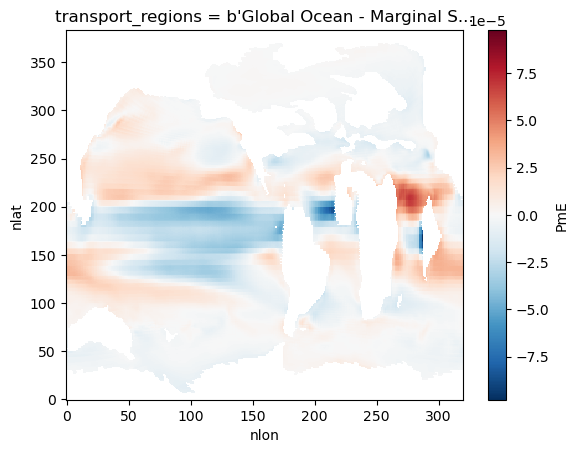

In [24]:
dsOrbMaxN['PmE'].mean('time').plot()

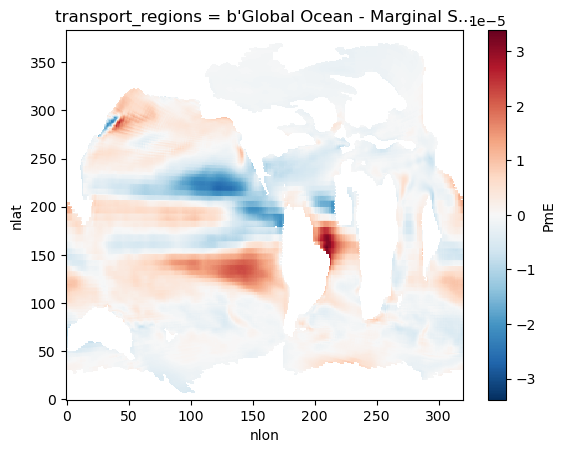

In [25]:
dsOrbMaxS['PmE'].mean('time').plot()

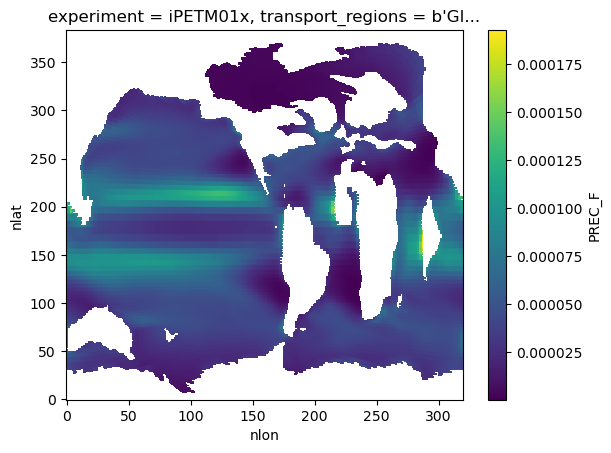

In [15]:
ds['PREC_F'].mean('time').sel(experiment='iPETM01x').plot()